# Testando conexão SQL SERVER no DOCKER

In [1]:
!pip install pyodbc sqlalchemy

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# Configuração de conexão
USER = "sa"
PASSWORD = "SENHAFORTESQLsenhanova123"  
HOST = "sqlserver_db"                   # Nome do serviço na rede do Docker
PORT = "1433"
DATABASE = "AdventureWorks2022"      

# Monta a conexão automaticamente
connection_url = f"mssql+pyodbc://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}?driver=ODBC+Driver+17+for+SQL+Server"
engine = create_engine(connection_url)

# A query de vendas testada
query = """
SELECT 
    sod.SalesOrderID,
    soh.OrderDate,
    p.Name AS ProductName,
    sod.OrderQty,
    sod.LineTotal
FROM Sales.SalesOrderDetail sod
INNER JOIN Sales.SalesOrderHeader soh ON sod.SalesOrderID = soh.SalesOrderID
INNER JOIN Production.Product p ON sod.ProductID = p.ProductID;
"""

# dataframe da query
df = pd.read_sql(query, engine)
print(f"Sucesso total! Linhas carregadas no Pandas: {len(df)}")
df.head()


Sucesso total! Linhas carregadas no Pandas: 121317


,SalesOrderID,OrderDate,ProductName,OrderQty,LineTotal
0,43659,2011-05-31,"Mountain-100 Black, 42",1,2024.994
1,43659,2011-05-31,"Mountain-100 Black, 44",3,6074.982
2,43659,2011-05-31,"Mountain-100 Black, 48",1,2024.994
3,43659,2011-05-31,"Mountain-100 Silver, 38",1,2039.994
4,43659,2011-05-31,"Mountain-100 Silver, 42",1,2039.994


# Consulta para segmentação de clientes e algoritmo ML ( agrupamento )
- Recência: Dias desde a última compra.
- Frequência: Total de pedidos.
- Valor Monetário: Total gasto pelo cliente.

In [3]:
QueryAgrupamento = """
SELECT 
    CustomerID,
    DATEDIFF(day, MAX(orderDate), (SELECT MAX(orderDate) FROM Sales.SalesOrderHeader)) AS Recencia_Dias,
    SUM(TotalDue) AS Valor_Monetario,
    COUNT(SalesOrderID) AS Frequencia_Pedidos
FROM Sales.SalesOrderHeader
WHERE Status <> 6 
GROUP BY CustomerID;
"""

df_agrupamento = pd.read_sql(QueryAgrupamento, engine)
print(f"Sucesso total! Linhas carregadas no Pandas: {len(df_agrupamento)}")
df_agrupamento.head()

Sucesso total! Linhas carregadas no Pandas: 19119


,CustomerID,Recencia_Dias,Valor_Monetario,Frequencia_Pedidos
0,14324,134,5659.1783,3
1,22814,310,5.5140,1
2,11407,219,59.6590,1
3,28387,71,645.2869,1
4,19897,70,659.6408,1


In [4]:
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df_agrupamento[["Recencia_Dias", "Frequencia_Pedidos", "Valor_Monetario"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_agrupamento["Grupo_Cliente"] = kmeans.fit_predict(X_scaled)

perfil_grupos = (df_agrupamento.groupby("Grupo_Cliente")[["Recencia_Dias","Frequencia_Pedidos", "Valor_Monetario"]].mean().round(2))

print("--- Perfil médio de cada grupo (clusters) ---")
print(perfil_grupos)

--- Perfil médio de cada grupo (clusters) ---
               Recencia_Dias  Frequencia_Pedidos  Valor_Monetario
Grupo_Cliente                                                    
0                      95.65                1.72          3045.24
1                     278.45                1.31          1731.33
2                     124.62               10.43        303971.60
3                     885.39                1.34         11821.32


## Avaliação 
- Recência baixa + Frequência alta + Valor alto = Melhores clientes (VIP).
- Recência alta + Frequência baixa + Valor baixo = Cleintes sumidos ou de baixo valor.
- Recência baixa + Frequência baixa + Valor baixo = Novos clientes

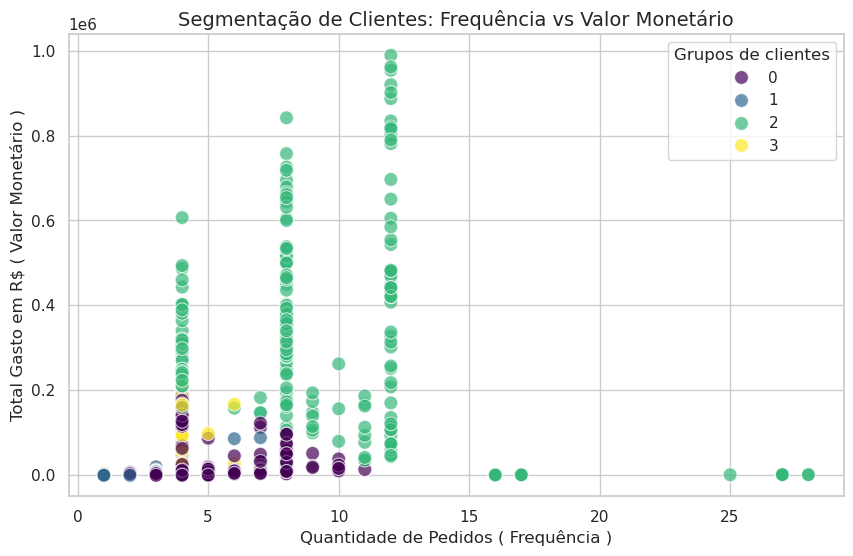

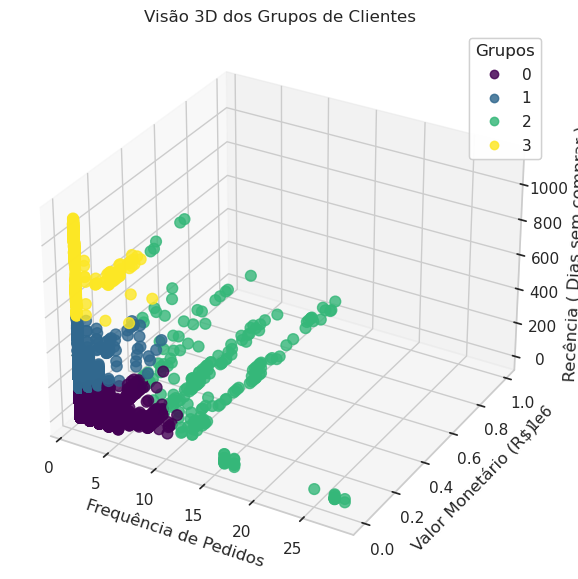

In [ ]:
import seaborn as sns 

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))
sns.scatterplot(
    data = df_agrupamento,
    x="Frequencia_Pedidos",
    y="Valor_Monetario",
    hue="Grupo_Cliente", # PInta de acordo com o grupo
    palette = "viridis", # Paleta de cores utilizada
    s=100, # Tamanho das bolinhas
    alpha=0.7,
)

plt.title("Segmentação de Clientes: Frequência vs Valor Monetário", fontsize=14)
plt.xlabel("Quantidade de Pedidos ( Frequência )", fontsize=12)
plt.ylabel("Total Gasto em R$ ( Valor Monetário )", fontsize=12)
plt.legend(title="Grupos de clientes")
plt.show()

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df_agrupamento["Frequencia_Pedidos"],
    df_agrupamento["Valor_Monetario"],
    df_agrupamento["Recencia_Dias"],
    c=df_agrupamento["Grupo_Cliente"],
    cmap="viridis",
    s=60,
    alpha=0.8,
)

ax.set_title("Visão 3D dos Grupos de Clientes")
ax.set_xlabel("Frequência de Pedidos")
ax.set_ylabel("Valor Monetário (R$)")
ax.set_zlabel("Recência ( Dias sem comprar )")

legend = ax.legend(*scatter.legend_elements(), title="Grupos")
ax.add_artist(legend)
plt.show()

/tmp/ipykernel_1191/1073920803.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


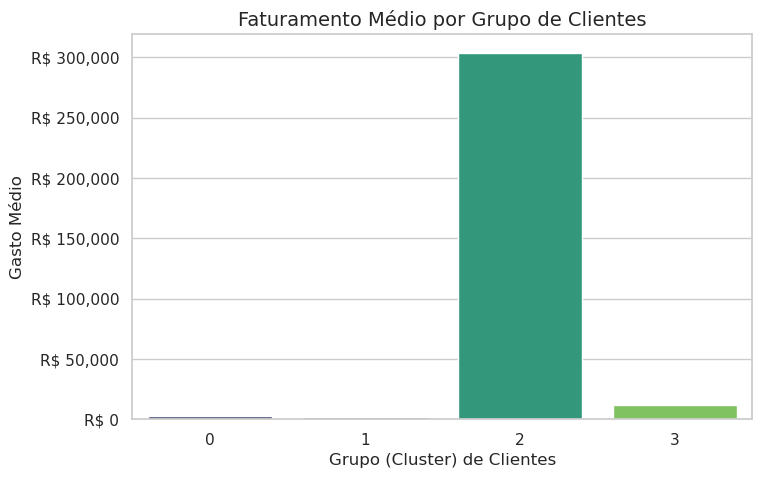

In [6]:
df_grupos_barras = df_agrupamento.groupby("Grupo_Cliente")["Valor_Monetario"].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(
        data=df_grupos_barras,
        x="Grupo_Cliente",
        y="Valor_Monetario",
        palette="viridis"   
    )  

plt.title("Faturamento Médio por Grupo de Clientes", fontsize=14)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}"))
plt.xlabel("Grupo (Cluster) de Clientes", fontsize=12)
plt.ylabel("Gasto Médio", fontsize=12)
plt.show()

/tmp/ipykernel_1191/999956783.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


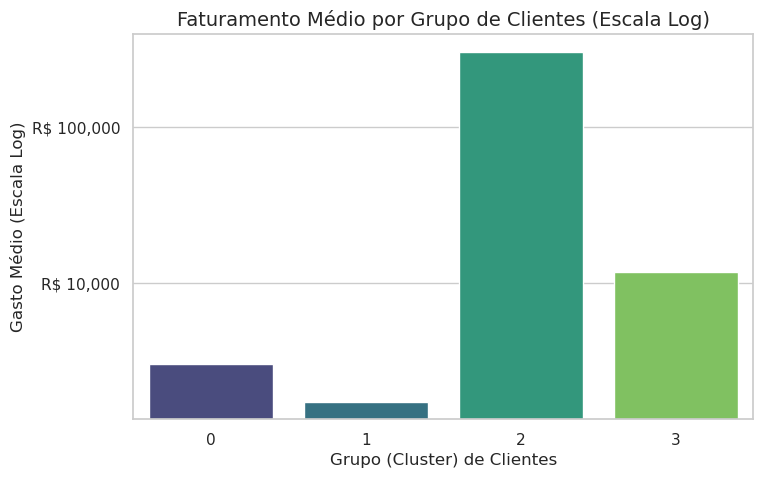

In [ ]:
df_barras = df_agrupamento.groupby("Grupo_Cliente")["Valor_Monetario"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_barras,
    x="Grupo_Cliente",
    y="Valor_Monetario",
    palette="viridis"
)

# O PULO DO GATO: Aplica escala logarítmica no eixo Y para visualizar todas as grandezas juntas
plt.yscale('log')

plt.title("Faturamento Médio por Grupo de Clientes (Escala Log)", fontsize=14)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}"))
plt.xlabel("Grupo (Cluster) de Clientes", fontsize=12)
plt.ylabel("Gasto Médio (Escala Log)", fontsize=12)
plt.show()


# Separando B2C

In [8]:
QuerySegmentada = """
SELECT 
    c.CustomerID,
    -- Identifica se é B2B (possui Loja cadastrada) ou B2C (Pessoa Física)
    CASE 
        WHEN c.StoreID IS NOT NULL THEN 'B2B'
        ELSE 'B2C'
    END AS Tipo_Mercado,
    DATEDIFF(day, MAX(oh.OrderDate), (SELECT MAX(OrderDate) FROM Sales.SalesOrderHeader)) AS Recencia_Dias,
    COUNT(oh.SalesOrderID) AS Frequencia_Pedidos,
    SUM(oh.TotalDue) AS Valor_Monetario
FROM Sales.Customer c
INNER JOIN Sales.SalesOrderHeader oh ON c.CustomerID = oh.CustomerID
WHERE oh.Status <> 6 -- Ignora cancelados
GROUP BY c.CustomerID, c.StoreID;
"""

df_completo = pd.read_sql_query(QuerySegmentada, engine)


In [9]:
df_b2c = df_completo[df_completo["Tipo_Mercado"] == "B2C"].copy()

df_b2b = df_completo[df_completo["Tipo_Mercado"] == "B2B"].copy()

print(f"Total de Clientes B2C: {len(df_b2c)}")
print(f"Total de Clientes B2B: {len(df_b2b)}")

Total de Clientes B2C: 18484
Total de Clientes B2B: 635


## K-Means apenas B2C

/tmp/ipykernel_1191/4173268975.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_barras_b2c, x="Grupo_B2C", y="Valor_Monetario", palette="magma")


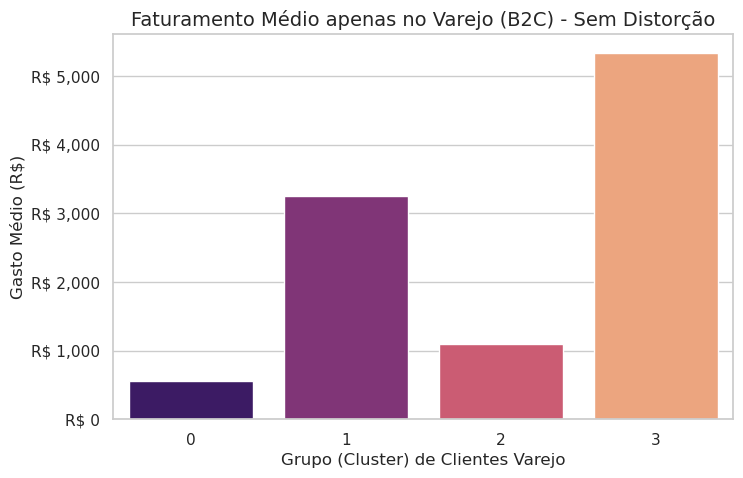

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Escalonar apenas os dados B2C
X_b2c = df_b2c[["Recencia_Dias", "Frequencia_Pedidos", "Valor_Monetario"]]
scaler_b2c = StandardScaler()
X_b2c_scaled = scaler_b2c.fit_transform(X_b2c)

# 2. Treinar o K-Means para o varejo (vamos manter 4 grupos para o varejo)
kmeans_b2c = KMeans(n_clusters=4, random_state=42, n_init=10)
df_b2c["Grupo_B2C"] = kmeans_b2c.fit_predict(X_b2c_scaled)

# 3. Gerar o Gráfico de Barras Realista do B2C (Quem mais rende no varejo?)
df_barras_b2c = df_b2c.groupby("Grupo_B2C")["Valor_Monetario"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=df_barras_b2c, x="Grupo_B2C", y="Valor_Monetario", palette="magma")

plt.title("Faturamento Médio apenas no Varejo (B2C) - Sem Distorção", fontsize=14)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}"))
plt.xlabel("Grupo (Cluster) de Clientes Varejo", fontsize=12)
plt.ylabel("Gasto Médio (R$)", fontsize=12)
plt.show()


## K-Means apenas B2B

/tmp/ipykernel_1191/567829428.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_barras_b2b, x="Grupo_B2B", y="Valor_Monetario", palette="viridis")


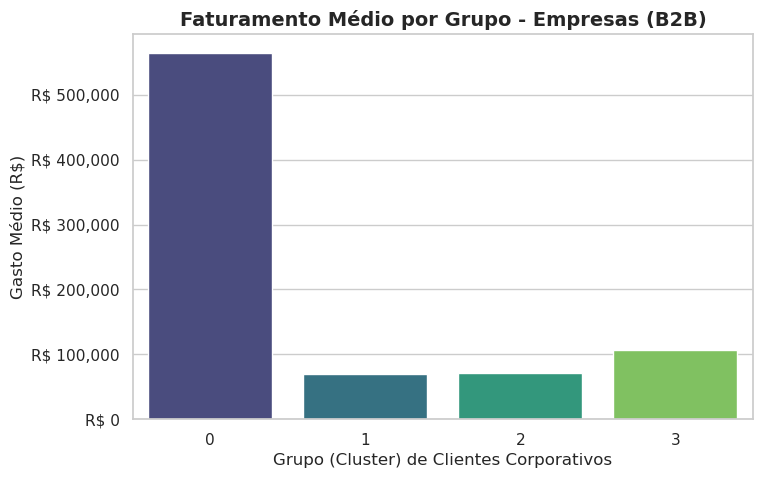

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Separar as colunas numéricas exclusivas do B2B
X_b2b = df_b2b[["Recencia_Dias", "Frequencia_Pedidos", "Valor_Monetario"]]

# 2. Normalizar os dados do B2B
scaler_b2b = StandardScaler()
X_b2b_scaled = scaler_b2b.fit_transform(X_b2b)

# 3. Treinar o modelo K-Means com 4 grupos para as empresas
kmeans_b2b = KMeans(n_clusters=4, random_state=42, n_init=10)
df_b2b["Grupo_B2B"] = kmeans_b2b.fit_predict(X_b2b_scaled)

# 4. Agrupar a média de faturamento por grupo para o gráfico
df_barras_b2b = df_b2b.groupby("Grupo_B2B")["Valor_Monetario"].mean().reset_index()

# 5. Plotar o gráfico isolado do B2B
plt.figure(figsize=(8, 5))
sns.barplot(data=df_barras_b2b, x="Grupo_B2B", y="Valor_Monetario", palette="viridis")

plt.title("Faturamento Médio por Grupo - Empresas (B2B)", fontsize=14, fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}"))
plt.xlabel("Grupo (Cluster) de Clientes Corporativos", fontsize=12)
plt.ylabel("Gasto Médio (R$)", fontsize=12)
plt.show()


# B2B x B2C

/tmp/ipykernel_1191/596498293.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1191/596498293.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


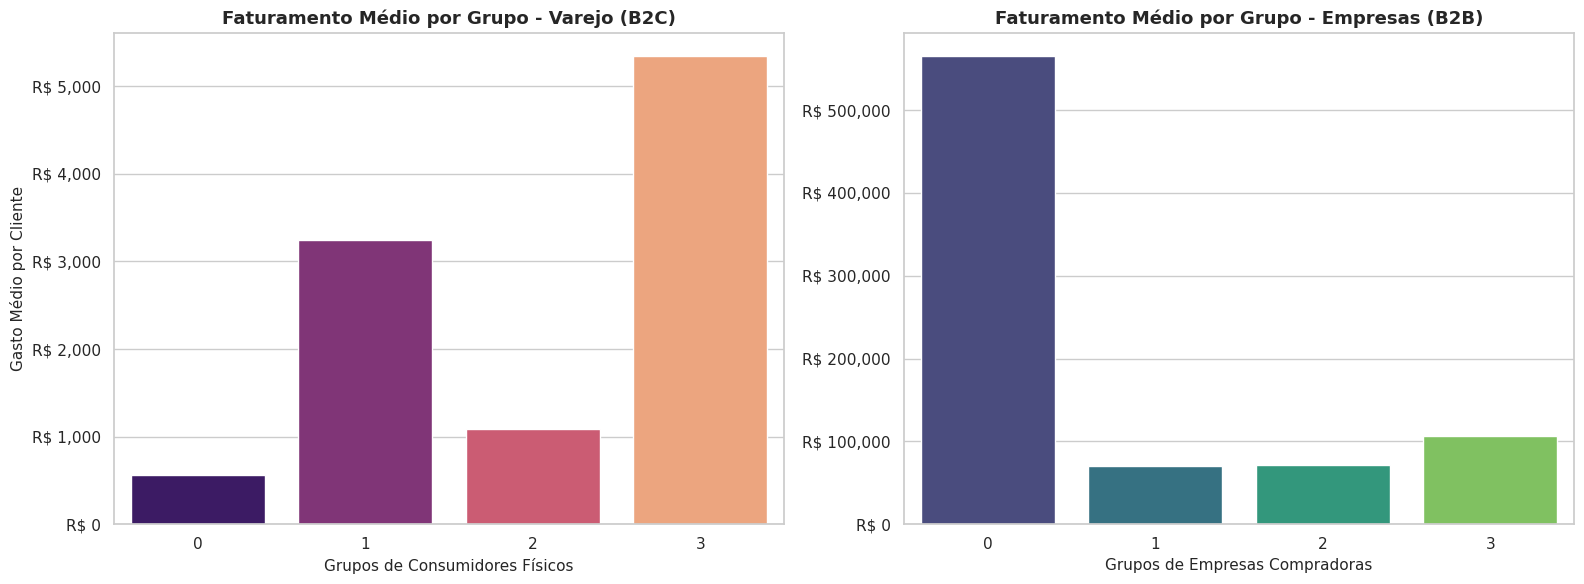

In [ ]:
# 1. Calcular as médias de faturamento de cada mercado
df_barras_b2c = df_b2c.groupby("Grupo_B2C")["Valor_Monetario"].mean().reset_index()
df_barras_b2b = df_b2b.groupby("Grupo_B2B")["Valor_Monetario"].mean().reset_index()

# 2. Configurar a janela para dois gráficos lado a lado (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico da Esquerda: Varejo (B2C) ---
sns.barplot(
    data=df_barras_b2c, 
    x="Grupo_B2C", 
    y="Valor_Monetario", 
    palette="magma", 
    ax=ax1
)
ax1.set_title("Faturamento Médio por Grupo - Varejo (B2C)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Grupos de Consumidores Físicos", fontsize=11)
ax1.set_ylabel("Gasto Médio por Cliente", fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}"))

# --- Gráfico da Direita: Corporativo (B2B) ---
sns.barplot(
    data=df_barras_b2b, 
    x="Grupo_B2B", 
    y="Valor_Monetario", 
    palette="viridis", 
    ax=ax2
)
ax2.set_title("Faturamento Médio por Grupo - Empresas (B2B)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Grupos de Empresas Compradoras", fontsize=11)
ax2.set_ylabel("") # Remove o título do eixo Y para manter o visual limpo
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}"))

# 3. Ajustar automaticamente o espaçamento das bordas
plt.tight_layout()
plt.show()


/tmp/ipykernel_1191/4079442488.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1191/4079442488.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


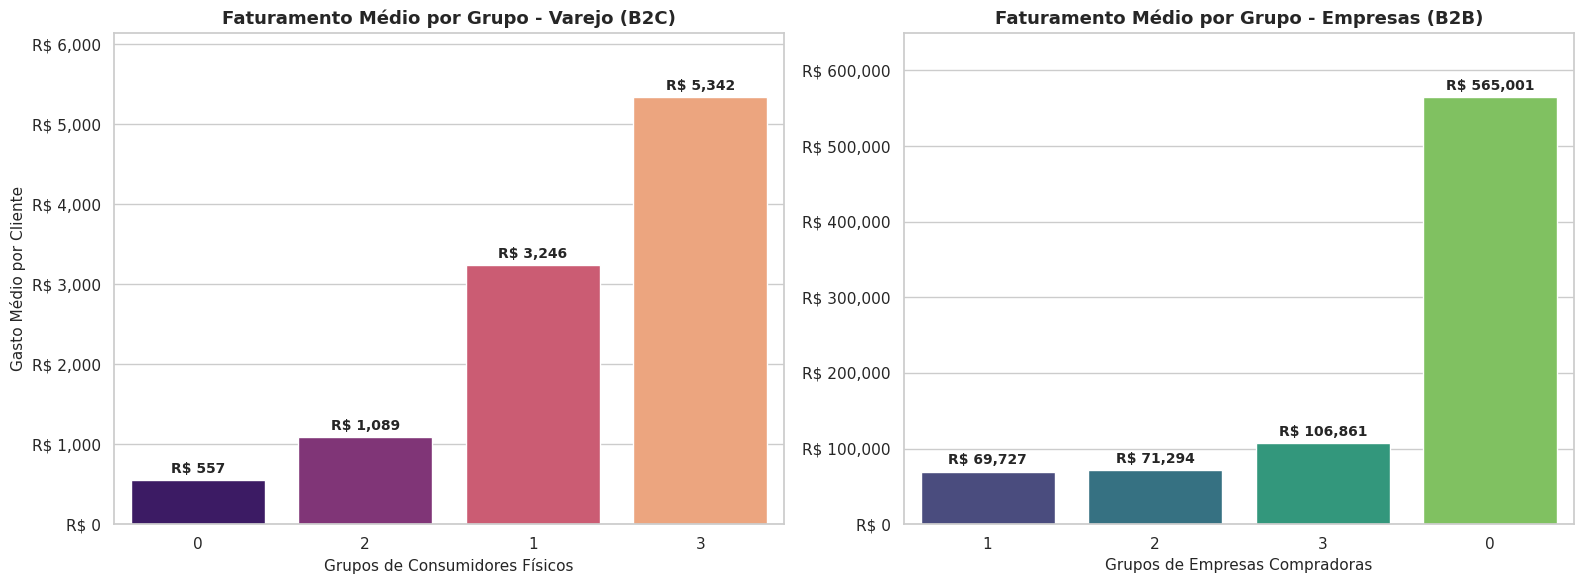

In [ ]:
# 1. Calcular as médias de faturamento de cada mercado e ORDENAR os valores
df_barras_b2c = (
    df_b2c.groupby("Grupo_B2C")["Valor_Monetario"]
    .mean()
    .reset_index()
    .sort_values(by="Valor_Monetario")  # Ordena do menor gasto para o maior
)

df_barras_b2b = (
    df_b2b.groupby("Grupo_B2B")["Valor_Monetario"]
    .mean()
    .reset_index()
    .sort_values(by="Valor_Monetario")  # Ordena do menor gasto para o maior
)

# 2. Configurar a janela para dois gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico da Esquerda: Varejo (B2C) ---
# Usamos 'order' para fixar a sequência que o pandas ordenou
sns.barplot(
    data=df_barras_b2c,
    x="Grupo_B2C",
    y="Valor_Monetario",
    order=df_barras_b2c["Grupo_B2C"],
    palette="magma",
    ax=ax1,
)
ax1.set_title(
    "Faturamento Médio por Grupo - Varejo (B2C)",
    fontsize=13,
    fontweight="bold",
)
ax1.set_xlabel("Grupos de Consumidores Físicos", fontsize=11)
ax1.set_ylabel("Gasto Médio por Cliente", fontsize=11)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}")
)

# Adiciona o texto com o valor exato no topo de cada barra do B2C
for p in ax1.patches:
    ax1.annotate(
        f"R$ {p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )


# --- Gráfico da Direita: Corporativo (B2B) ---
sns.barplot(
    data=df_barras_b2b,
    x="Grupo_B2B",
    y="Valor_Monetario",
    order=df_barras_b2b["Grupo_B2B"],
    palette="viridis",
    ax=ax2,
)
ax2.set_title(
    "Faturamento Médio por Grupo - Empresas (B2B)",
    fontsize=13,
    fontweight="bold",
)
ax2.set_xlabel("Grupos de Empresas Compradoras", fontsize=11)
ax2.set_ylabel("")  # Remove o título do eixo Y para manter o visual limpo
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}")
)

# Adiciona o texto com o valor exato no topo de cada barra do B2B
for p in ax2.patches:
    ax2.annotate(
        f"R$ {p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )


# 3. Ajustar automaticamente o espaçamento das bordas e dar uma folga no topo para os textos
ax1.set_ylim(0, df_barras_b2c["Valor_Monetario"].max() * 1.15)
ax2.set_ylim(0, df_barras_b2b["Valor_Monetario"].max() * 1.15)

plt.tight_layout()
plt.show()


## Cenário B2C

- Quem são os principais compradores? O Grupo 3 é o cluster de ciclistas de elite do varejo, gastando uma média expressiva de R$ 5.342 em compras individuais. São entusiastas que compram bicicletas de fibra de carbono de alto valor.

- Como engajar compradores que ainda gastam pouco (Grupo 0 e 2)? O Grupo 0 gasta apenas R$ 557 em média (provavelmente compram apenas capacetes, garrafas d'água ou roupas de ciclismo). Para engajá-los, o marketing deve disparar campanhas de Up-Selling (oferecer um modelo de bicicleta de entrada focado em quem já consome acessórios) ou oferecer cupons de frete grátis combinados com o sistema de recomendação.

 ## Cenário B2B

 - Quem são os principais compradores? O Grupo 0 é composto pelas grandes redes de varejo parceiras. Embora sejam poucos clientes em quantidade, eles geram um ticket médio impressionante de R$ 565.001, tornando-se o coração da receita da empresa.

 - Como engajar os grupos menores (1, 2 e 3)? Esses grupos têm faturamentos médios muito menores (entre R$ 69k e R$ 106k). O plano de ação para vendas é criar políticas de descontos progressivos por volume (ex: compre mais de 50 bicicletas e ganhe 15% de desconto) ou estender prazos de pagamento para tentar transformá-los gradualmente em clientes do Grupo 0.

# Compra casada ( Algoritmo Apriori )

## Query compra casada

In [14]:
# 1. Definir a consulta SQL para buscar os produtos de cada carrinho de compras
QueryVendaCasada = """
SELECT 
    sod.SalesOrderID AS TransacaoID,
    p.Name AS NomeProduto
FROM Sales.SalesOrderDetail sod
INNER JOIN Production.Product p ON sod.ProductID = p.ProductID
INNER JOIN Sales.SalesOrderHeader soh ON sod.SalesOrderID = soh.SalesOrderID
WHERE soh.Status <> 6; -- Ignora os pedidos que foram cancelados
"""

# 2. Carregar os dados usando o seu engine de conexão
df_venda_casada = pd.read_sql_query(QueryVendaCasada, engine)

# 3. Validar se os dados vieram corretamente
print(f"Sucesso! Total de itens carregados: {len(df_venda_casada)}")
df_venda_casada.head(10)


Sucesso! Total de itens carregados: 121317


,TransacaoID,NomeProduto
0,43665,"Sport-100 Helmet, Red"
1,43668,"Sport-100 Helmet, Red"
2,43673,"Sport-100 Helmet, Red"
3,43677,"Sport-100 Helmet, Red"
4,43678,"Sport-100 Helmet, Red"
5,43680,"Sport-100 Helmet, Red"
6,43681,"Sport-100 Helmet, Red"
7,43683,"Sport-100 Helmet, Red"
8,43692,"Sport-100 Helmet, Red"
9,43693,"Sport-100 Helmet, Red"


## Formatar a Matriz de Compras ( One-Hot Encoding )

In [15]:
# 1. Agrupar os produtos por transação e criar uma tabela dinâmica (linhas = pedidos, colunas = produtos)
basket = (
    df_venda_casada.groupby(["TransacaoID", "NomeProduto"])["NomeProduto"]
    .count()
    .unstack()
    .reset_index()
    .fillna(0)
    .set_index("TransacaoID")
)

# 2. Converter as quantidades em valores booleanos (True para comprou, False para não comprou)
basket_encoded = basket.applymap(lambda x: True if x > 0 else False)

print(f"Formato final da matriz de compras: {basket_encoded.shape} (Total de Pedidos x Total de Produtos)")
basket_encoded.head()


/tmp/ipykernel_1191/3031142562.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = basket.applymap(lambda x: True if x > 0 else False)


Formato final da matriz de compras: (31465, 266) (Total de Pedidos x Total de Produtos)


NomeProduto,AWC Logo Cap,All-Purpose Bike Stand,Bike Wash - Dissolver,Cable Lock,Chain,"Classic Vest, L","Classic Vest, M","Classic Vest, S",Fender Set - Mountain,Front Brakes,...,"Touring-3000 Yellow, 54","Touring-3000 Yellow, 58","Touring-3000 Yellow, 62",Water Bottle - 30 oz.,"Women's Mountain Shorts, L","Women's Mountain Shorts, M","Women's Mountain Shorts, S","Women's Tights, L","Women's Tights, M","Women's Tights, S"
TransacaoID,,,,,,,,,,,,,,,,,,,,,
43659,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43660,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43661,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43662,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
43663,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Algoritmo Apriori

In [16]:
!pip install mlxtend

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 8.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 6.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 6.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 6.1 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 3.6 MB/s eta 0:00:0000:0100:01

In [17]:
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Identificar combinações de produtos frequentes (presentes em pelo menos 1% de todas as vendas da loja)
frequent_itemsets = apriori(basket_encoded, min_support=0.01, use_colnames=True)

# 2. Gerar as regras de associação onde a Confiança (probabilidade de comprar o item B se já comprou o A) for maior que 40%
regras = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

# 3. Selecionar as colunas mais importantes e ordenar pelo Lift (força estatística da combinação)
regras_finais = regras[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values(by="lift", ascending=False)

print("--- Principais Combinações de Compra Casada Descobertas ---")
regras_finais.head(10)


--- Principais Combinações de Compra Casada Descobertas ---


,antecedents,consequents,support,confidence,lift
21307,"(Short-Sleeve Classic Jersey, XL, Hydration Pa...","(Sport-100 Helmet, Red, Bike Wash - Dissolver)",0.010011,0.975232,95.892753
21308,"(Sport-100 Helmet, Red, Bike Wash - Dissolver)","(Short-Sleeve Classic Jersey, XL, Hydration Pa...",0.010011,0.984375,95.892753
21071,"(Sport-100 Helmet, Red, Bike Wash - Dissolver)","(Long-Sleeve Logo Jersey, L, Hydration Pack - ...",0.010011,0.984375,95.892753
21062,"(Long-Sleeve Logo Jersey, L, Hydration Pack - ...","(Sport-100 Helmet, Red, Bike Wash - Dissolver)",0.010011,0.975232,95.892753
27933,"(Short-Sleeve Classic Jersey, XL, Hydration Pa...","(Sport-100 Helmet, Red, Long-Sleeve Logo Jerse...",0.010011,0.957447,94.736050
27919,"(Sport-100 Helmet, Red, Long-Sleeve Logo Jerse...","(Short-Sleeve Classic Jersey, XL, Hydration Pa...",0.010011,0.990566,94.736050
21315,"(Short-Sleeve Classic Jersey, XL, Hydration Pa...","(Sport-100 Helmet, Red, Bike Wash - Dissolver,...",0.010011,0.957447,94.736050
21300,"(Sport-100 Helmet, Red, Bike Wash - Dissolver,...","(Short-Sleeve Classic Jersey, XL, Hydration Pa...",0.010011,0.990566,94.736050
5012,"(Sport-100 Helmet, Red, Bike Wash - Dissolver)","(Short-Sleeve Classic Jersey, XL, Hydration Pa...",0.010011,0.984375,94.143949
5017,"(Short-Sleeve Classic Jersey, XL, Hydration Pa...","(Sport-100 Helmet, Red, Bike Wash - Dissolver)",0.010011,0.957447,94.143949


Antecedente: {Bike Wash - Dissolver (Limpador de Bicicleta) + Sport-100 Helmet, Red (Capacete Vermelho)}Conseqüente: {Short-Sleeve Classic Jersey (Camisa de Manga Curta)}O Insight de Negócio:Quem está comprando um capacete novo e um produto para lavar a bicicleta é o perfil do ciclista ativo/cuidadoso. Esse cliente tem 98.4% de chance de comprar também uma camisa de ciclismo na mesma transação.

Recomendação Inteligente no Carrinho: Se um cliente adicionar o Bike Wash e o Capacete no carrinho e tentar fechar a compra, o site deve disparar um pop-up imediato: "Não esqueça o seu uniforme! 98% dos ciclistas também levam esta Camisa Classic Jersey".Criação de Kits Promocionais: Criar um combo fechado chamado "Kit Ciclista Equipado" contendo o Limpador, o Capacete e a Camisa com um pequeno desconto de 5%. Isso incentiva quem ia comprar só o capacete a levar os três itens, aumentando o Ticket Médio da loja.Organização Física da Loja (Se fosse varejo físico): Colocar o produto de limpeza de bicicletas na mesma prateleira ou corredor das camisas e capacetes, facilitando a compra por impulso.

# Algoritmo de Churn ( Previsão de cancelamento )